# Task 1

## Part 1 :
This step involves downloading, preparing, and visualizing your
dataset. Create a convolutional base using a common pattern: a stack of Conv and
MaxPooling layers. Depending on the problem and the dataset you must decide what
pattern you want to use (i.e., how many Conv layers and how many pooling layers).
Please describe why you chose a particular pattern. Add the final dense layer(s).
Compile and train the model. Report the final evaluation and describe the metrics.

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


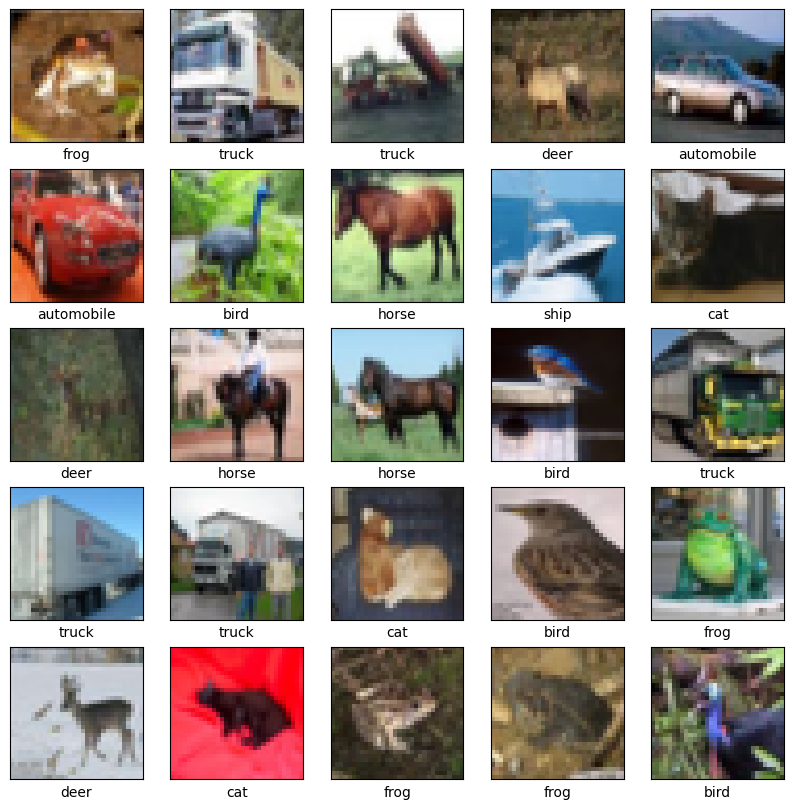

In [6]:
#Using the CIFAR dataset
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

#Load the dataset
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

In [18]:
#The neural network

model = models.Sequential()
model.add(layers.Input(shape=(32, 32, 3)))

# Block 1
model.add(layers.Conv2D(32, (3, 3)))
model.add(layers.BatchNormalization())
model.add(layers.LeakyReLU(negative_slope=0.1))
model.add(layers.MaxPooling2D((2, 2)))

# Block 2
model.add(layers.Conv2D(64, (3, 3)))
model.add(layers.BatchNormalization())
model.add(layers.LeakyReLU(negative_slope=0.1))
model.add(layers.MaxPooling2D((2, 2)))

# Block 3
model.add(layers.Conv2D(128, (3, 3))) # Increased to 128 filters
model.add(layers.BatchNormalization())
model.add(layers.LeakyReLU(negative_slope=0.1))
model.add(layers.MaxPooling2D((2, 2)))

# Block 4 (The New Block)
model.add(layers.Conv2D(128, (3, 3), padding='same')) # 'same' padding keeps dimensions stable
model.add(layers.BatchNormalization())
model.add(layers.LeakyReLU(negative_slope=0.1))

# Final Classification Head
model.add(layers.Flatten())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(128)) # Increased dense units to match the 128 filters
model.add(layers.LeakyReLU(negative_slope=0.1))
model.add(layers.Dense(10))

In [22]:
model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001, weight_decay=0.004),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Train the model
history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.8487 - loss: 0.4317 - val_accuracy: 0.7313 - val_loss: 0.8463
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8606 - loss: 0.3991 - val_accuracy: 0.7566 - val_loss: 0.7624
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8648 - loss: 0.3814 - val_accuracy: 0.7316 - val_loss: 0.9041
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8727 - loss: 0.3595 - val_accuracy: 0.7349 - val_loss: 0.8856
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8811 - loss: 0.3361 - val_accuracy: 0.7275 - val_loss: 0.9220
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8893 - loss: 0.3135 - val_accuracy: 0.7570 - val_loss: 0.8239
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8930 - loss: 0.2996 - val_accuracy: 0.7557 - val_loss: 0.8794
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8974 - loss: 0.2907 -

In [24]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f'\nFinal Test Accuracy: {test_acc:.4f}')

313/313 - 1s - 2ms/step - accuracy: 0.7277 - loss: 1.0480

Final Test Accuracy: 0.7277


In my program, I implemented a 4-block convolutional base. I chose a pattern of four Convolutional layers (increasing from 32 to 128 filters) to extract a hierarchy of features, from simple edges to complex shapes. I used three MaxPooling layers to reduce the spatial dimensions from $32 \times 32$ to a high-level $4 \times 4$ feature map.To improve performance, I integrated Batch Normalization after each convolution to stabilize training and LeakyReLU (with a negative slope of 0.1) to prevent the 'dying ReLU' problem. For regularization, I added a Dropout layer (0.5) before the final dense layers to reduce overfitting. Finally, I used the AdamW optimizer with an exponential learning rate decay to ensure the model converges efficiently



## Part 2
Using Residual Network, ResNet18

In [25]:
def residual_block(x, filters, kernel_size=3, stride=1):
    shortcut = x

    # First Layer of Block
    x = layers.Conv2D(filters, kernel_size, strides=stride, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)

    # Second Layer of Block
    x = layers.Conv2D(filters, kernel_size, strides=1, padding='same')(x)
    x = layers.BatchNormalization()(x)

    # Residual
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    return x

# ResNet18-style model
inputs = layers.Input(shape=(32, 32, 3))
x = layers.Conv2D(64, 3, padding='same')(inputs)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU(negative_slope=0.1)(x)

# Adding Residual Blocks
x = residual_block(x, 64)
x = residual_block(x, 64)
x = residual_block(x, 128, stride=2)
x = residual_block(x, 128)
x = residual_block(x, 256, stride=2)
x = residual_block(x, 256)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(10)(x)

model_resnet = models.Model(inputs, outputs)

# Compile and Train
model_resnet.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001, weight_decay=0.004),
                    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                    metrics=['accuracy'])

history_resnet = model_resnet.fit(train_images, train_labels, epochs=10, validation_data=(test_images, test_labels))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 17ms/step - accuracy: 0.4803 - loss: 1.4471 - val_accuracy: 0.5273 - val_loss: 1.2961
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6728 - loss: 0.9328 - val_accuracy: 0.7015 - val_loss: 0.8318
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.7480 - loss: 0.7309 - val_accuracy: 0.7482 - val_loss: 0.7524
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.7947 - loss: 0.6024 - val_accuracy: 0.7744 - val_loss: 0.6431
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8290 - loss: 0.5004 - val_accuracy: 0.7841 - val_loss: 0.6337
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8543 - loss: 0.4262 - val_accuracy: 0.7559 - val_loss: 0.7513
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8763 - loss: 0.3604 - val_accuracy: 0.8220 - val_loss: 0.5303
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8945 - loss: 

In [26]:
res_loss, res_acc = model_resnet.evaluate(test_images, test_labels, verbose=2)
print(f"ResNet18 Test Accuracy: {res_acc:.4f}")

313/313 - 1s - 4ms/step - accuracy: 0.8294 - loss: 0.5797
ResNet18 Test Accuracy: 0.8294


The difference we can notice is in the training the accuracy shot up in high intervals and the test accuracy was a lot better as compared to part 1. The ResNet18 model outperformed the CNN by over 10% accuracy and cut thest loss in half. The difference can be seen from the reductin of overfitting as ResNet18 uses GAP instead of a flatten layer and resnet 18 is able to capture better visual patterns.

## Part 3, Data Augmentation

In [4]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
#The neural network
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.1),  # Rotates up to 10%
  layers.RandomZoom(0.1),      # Zooms in/out up to 10%
])

model_aug = models.Sequential()
model_aug.add(layers.Input(shape=(32, 32, 3)))
model_aug.add(data_augmentation)

# Block 1
model_aug.add(layers.Conv2D(32, (3, 3)))
model_aug.add(layers.BatchNormalization())
model_aug.add(layers.LeakyReLU(negative_slope=0.1))
model_aug.add(layers.MaxPooling2D((2, 2)))

# Block 2
model_aug.add(layers.Conv2D(64, (3, 3)))
model_aug.add(layers.BatchNormalization())
model_aug.add(layers.LeakyReLU(negative_slope=0.1))
model_aug.add(layers.MaxPooling2D((2, 2)))

# Block 3
model_aug.add(layers.Conv2D(128, (3, 3))) # Increased to 128 filters
model_aug.add(layers.BatchNormalization())
model_aug.add(layers.LeakyReLU(negative_slope=0.1))
model_aug.add(layers.MaxPooling2D((2, 2)))

# Block 4 (The New Block)
model_aug.add(layers.Conv2D(128, (3, 3), padding='same'))
model_aug.add(layers.BatchNormalization())
model_aug.add(layers.LeakyReLU(negative_slope=0.1))

# Final Classification Head
model_aug.add(layers.Flatten())
model_aug.add(layers.Dropout(0.5))
model_aug.add(layers.Dense(128))
model_aug.add(layers.LeakyReLU(negative_slope=0.1))
model_aug.add(layers.Dense(10))

In [7]:
model_aug.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001, weight_decay=0.004),
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=['accuracy'])

history_aug = model_aug.fit(train_images, train_labels, epochs=10,
                            validation_data=(test_images, test_labels))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - accuracy: 0.4389 - loss: 1.5418 - val_accuracy: 0.5090 - val_loss: 1.3994
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.5463 - loss: 1.2730 - val_accuracy: 0.5956 - val_loss: 1.1484
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.5900 - loss: 1.1580 - val_accuracy: 0.5770 - val_loss: 1.2057
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.6195 - loss: 1.0868 - val_accuracy: 0.6349 - val_loss: 1.0298
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.6407 - loss: 1.0280 - val_accuracy: 0.5883 - val_loss: 1.1974
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.6562 - loss: 0.9777 - val_accuracy: 0.6487 - val_loss: 1.0178
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.6699 - loss: 0.9446 - val_accuracy: 0.6302 - val_loss: 1.0903
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.6829 -

In [9]:
test_loss, test_acc = model_aug.evaluate(test_images, test_labels, verbose=2)
print(f'\nFinal Test Accuracy with Data Augmenetation: {test_acc:.4f}')

313/313 - 1s - 3ms/step - accuracy: 0.7134 - loss: 0.8572

Final Test Accuracy with Data Augmenetation: 0.7134


Differences in results
In the training test cases we can highlight that the accuracy representation is not the same only because when i was testing i had reran the part 1 model which worked with the previous ran so i think it was 20 epochs instead of 10 hypothetically. But if we take a look at the accuaracy at face value, it actually appears  to have lower accuracy, but the accuracy on the testing set is about the same by a difference of .01. In this we notice that our Training and Testing accuracy is nearly the same which means our model isnt memorizing as compared to the first set of data. The introduction of this introduces generalization.

# Task 2

## Part 1, using the same data set

In [14]:
import numpy as np
class CVAE(tf.keras.Model):
  """Convolutional variational autoencoder."""
  def __init__(self, latent_dim):
    super(CVAE, self).__init__()
    self.latent_dim = latent_dim

    # Encoder: Compress 32x32x3 down to latent vector
    self.encoder = tf.keras.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, 3, strides=2, activation='relu'),
        layers.Conv2D(64, 3, strides=2, activation='relu'),
        layers.Flatten(),
        # Output 2*latent_dim (one for mean, one for log-variance)
        layers.Dense(latent_dim + latent_dim),
    ])

    # Decoder: Reconstruct 32x32x3 from latent vector
    self.decoder = tf.keras.Sequential([
        layers.Input(shape=(latent_dim,)),
        layers.Dense(units=8*8*32, activation=tf.nn.relu),
        layers.Reshape(target_shape=(8, 8, 32)),
        layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu'),
        layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu'),
        layers.Conv2DTranspose(3, 3, strides=1, padding='same'), # Output RGB
    ])

  @tf.function
  def sample(self, eps=None):
    if eps is None:
      eps = tf.random.normal(shape=(100, self.latent_dim))
    return self.decode(eps, apply_sigmoid=True)

  def encode(self, x):
    mean, logvar = tf.split(self.encoder(x), num_or_size_splits=2, axis=1)
    return mean, logvar

  def reparameterize(self, mean, logvar):
    eps = tf.random.normal(shape=mean.shape)
    return eps * tf.exp(logvar * .5) + mean

  def decode(self, z, apply_sigmoid=False):
    logits = self.decoder(z)
    if apply_sigmoid:
      return tf.sigmoid(logits)
    return logits

In [16]:
optimizer = tf.keras.optimizers.Adam(1e-4)

def log_normal_pdf(sample, mean, logvar, raxis=1):
  log2pi = tf.math.log(2. * np.pi)
  return tf.reduce_sum(
      -.5 * ((sample - mean) ** 2. * tf.exp(-logvar) + logvar + log2pi),
      axis=raxis)

def compute_loss(model, x):
  mean, logvar = model.encode(x)
  z = model.reparameterize(mean, logvar)
  x_logit = model.decode(z)
  cross_ent = tf.nn.sigmoid_cross_entropy_with_logits(logits=x_logit, labels=x)
  logpx_z = -tf.reduce_sum(cross_ent, axis=[1, 2, 3])
  logpz = log_normal_pdf(z, 0., 0.)
  logqz_x = log_normal_pdf(z, mean, logvar)
  return -tf.reduce_mean(logpx_z + logpz - logqz_x)

@tf.function
def train_step(model, x, optimizer):
  with tf.GradientTape() as tape:
    loss = compute_loss(model, x)
  gradients = tape.gradient(loss, model.trainable_variables)
  optimizer.apply_gradients(zip(gradients, model.trainable_variables))

In [17]:
latent_dim = 16
model = CVAE(latent_dim)

train_images_32 = train_images.astype('float32')

train_dataset = tf.data.Dataset.from_tensor_slices(train_images_32).shuffle(50000).batch(32)

for epoch in range(1, 11):
  for train_x in train_dataset:
    train_step(model, train_x, optimizer)
  print(f'Epoch {epoch} complete')

Epoch 1 complete
Epoch 2 complete
Epoch 3 complete
Epoch 4 complete
Epoch 5 complete
Epoch 6 complete
Epoch 7 complete
Epoch 8 complete
Epoch 9 complete
Epoch 10 complete


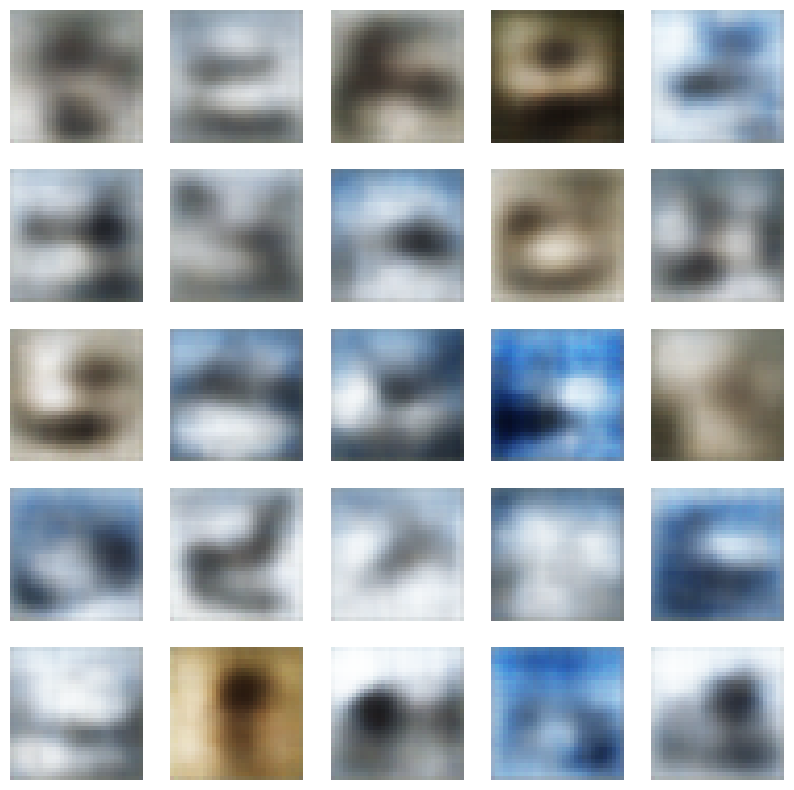

In [18]:
import matplotlib.pyplot as plt

def display_generated_images(model, n=5):
    # Sample from the latent space
    random_latent_vectors = tf.random.normal(shape=(n**2, 16))
    predictions = model.sample(random_latent_vectors)

    plt.figure(figsize=(10, 10))
    for i in range(predictions.shape[0]):
        plt.subplot(n, n, i+1)
        plt.imshow(predictions[i])
        plt.axis('off')
    plt.show()

display_generated_images(model)

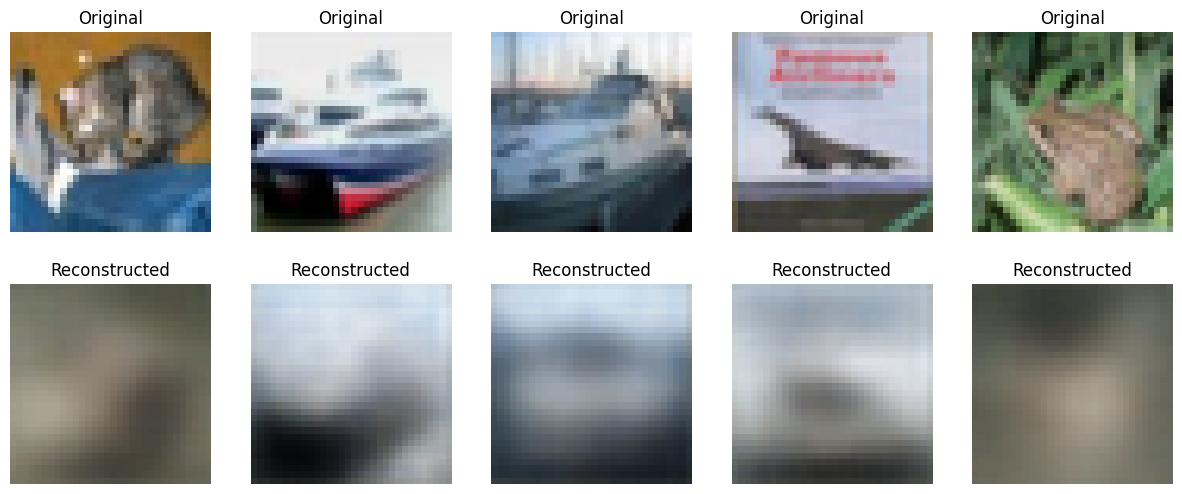

In [19]:
def compare_reconstruction(model, images):
    mean, logvar = model.encode(images[:5])
    z = model.reparameterize(mean, logvar)
    reconstructions = model.decode(z, apply_sigmoid=True)

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    for i in range(5):

        # Original
        axes[0, i].imshow(images[i])
        axes[0, i].set_title("Original")
        axes[0, i].axis('off')

        # Reconstruction
        axes[1, i].imshow(reconstructions[i])
        axes[1, i].set_title("Reconstructed")
        axes[1, i].axis('off')
    plt.show()

compare_reconstruction(model, test_images.astype('float32'))

## Part 2 using GAN

In [20]:
def make_generator_model():
    model = tf.keras.Sequential()
    model.add(layers.Dense(8*8*256, use_bias=False, input_shape=(100,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((8, 8, 256)))

    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Final layer outputs 32x32x3 (CIFAR size)
    model.add(layers.Conv2DTranspose(3, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))

    return model

def make_discriminator_model():
    model = tf.keras.Sequential()
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=[32, 32, 3]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model

In [21]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

In [22]:
generator = make_generator_model()
discriminator = make_discriminator_model()

@tf.function
def train_step(images):
    noise = tf.random.normal([32, 100])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
      generated_images = generator(noise, training=True)

      real_output = discriminator(images, training=True)
      fake_output = discriminator(generated_images, training=True)

      gen_loss = generator_loss(fake_output)
      disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

# Run training
for epoch in range(20):
    for image_batch in train_dataset:
        train_step(image_batch)
    print(f'Epoch {epoch+1} completed')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
Epoch 6 completed
Epoch 7 completed
Epoch 8 completed
Epoch 9 completed
Epoch 10 completed
Epoch 11 completed
Epoch 12 completed
Epoch 13 completed
Epoch 14 completed
Epoch 15 completed
Epoch 16 completed
Epoch 17 completed
Epoch 18 completed
Epoch 19 completed
Epoch 20 completed


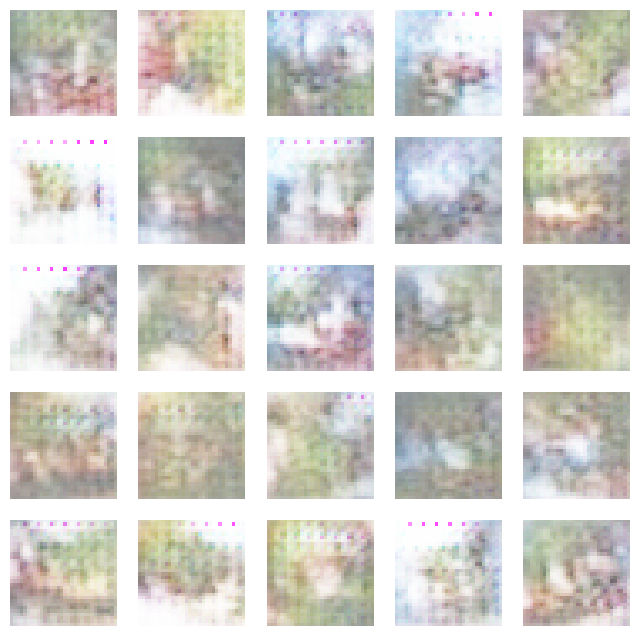

In [23]:
def plot_gan_images(generator, n=5):
    noise = tf.random.normal([n*n, 100])
    images = generator(noise, training=False)
    # Rescale from [-1, 1] to [0, 1] for plotting
    images = (images + 1) / 2.0

    plt.figure(figsize=(8,8))
    for i in range(images.shape[0]):
        plt.subplot(n, n, i+1)
        plt.imshow(images[i])
        plt.axis('off')
    plt.show()

plot_gan_images(generator)

# Task 3

Part 1 Scaled dot product attention

In [24]:
import numpy as np
import pandas as pd

def scaled_dot_product_attention_np(Q, K, V, mask=None):
    """
    Q, K, V: Input matrices
    mask: Optional mask to ignore specific tokens (padding/future)
    """
    d_k = Q.shape[-1]

    # Dot product of Q and K transposed
    scores = np.matmul(Q, K.T) / np.sqrt(d_k)

    # Apply mask
    if mask is not None:
        scores = np.where(mask == 0, -1e9, scores)

    # Softmax along the last axis
    weights = np.exp(scores - np.max(scores, axis=-1, keepdims=True))
    weights /= np.sum(weights, axis=-1, keepdims=True)

    # Multiply by V
    output = np.matmul(weights, V)
    return output, weights

Part 2 Seq2Seq wth Scaled Dot-Product Attention

In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class AttnDecoder(nn.Module):
    def __init__(self, hidden_size, output_size):
        super(AttnDecoder, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size * 2, output_size)

    def forward(self, input, hidden, encoder_outputs):
        # 1. Embed current token
        embedded = self.embedding(input).view(1, 1, -1)

        # 2. Pass through GRU
        output, hidden = self.gru(embedded, hidden)

        # 3. Scaled Dot-Product Attention (Integration from Part 1)
        # Q: Decoder hidden state (output), K/V: Encoder outputs
        d_k = self.hidden_size
        scores = torch.bmm(output, encoder_outputs.transpose(1, 2)) / (d_k ** 0.5)
        attn_weights = F.softmax(scores, dim=-1)
        context = torch.matmul(attn_weights, encoder_outputs)

        # 4. Concatenate context and output for final prediction
        combined = torch.cat((output, context), dim=2)
        output = F.log_softmax(self.out(combined[0]), dim=1)

        return output, hidden, attn_weights

In [31]:
import pandas as pd
import requests
import zipfile
import io
import os

# Download the English-German Anki subset
url = "http://www.manythings.org/anki/deu-eng.zip"

# Expanded headers to resolve the 406 error
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36',
    'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8',
    'Accept-Language': 'en-US,en;q=0.5',
}

print("Attempting to download...")
r = requests.get(url, headers=headers)

if r.status_code == 200:
    try:
        z = zipfile.ZipFile(io.BytesIO(r.content))
        z.extractall()
        print("Download and extraction successful!")

        # Verify the file exists before loading
        if os.path.exists('deu.txt'):
            # Load into Pandas
            df = pd.read_csv('deu.txt', sep='\t', header=None, names=['en', 'de', 'attr'], usecols=['en', 'de'])
            df_subset = df.iloc[:10000]
            print(f"Loaded {len(df_subset)} Tatoeba sentence pairs.")
            print(df_subset.head())
        else:
            print("Error: deu.txt not found in the extracted files.")

    except zipfile.BadZipFile:
        print("Error: The downloaded content is not a valid zip file.")
else:
    print(f"Failed to download file. Status code: {r.status_code}")
    print("The website might be temporarily blocking automated downloads. Try running the cell again in a minute.")

Attempting to download...
Download and extraction successful!
Loaded 10000 Tatoeba sentence pairs.
     en          de
0   Go.        Geh.
1   Hi.      Hallo!
2   Hi.  Grüß Gott!
3  Run!       Lauf!
4  Run.       Lauf!


In [32]:
import torch
from torch.utils.data import Dataset, DataLoader

class vocab_builder:
    def __init__(self):
        self.word2idx = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2, "<UNK>": 3}
        self.idx2word = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>"}
        self.num_words = 4

    def add_sentence(self, sentence):
        for word in sentence.split():
            if word not in self.word2idx:
                self.word2idx[word] = self.num_words
                self.idx2word[self.num_words] = word
                self.num_words += 1

# Prepare Vocab
en_vocab = vocab_builder()
de_vocab = vocab_builder()

for _, row in df_subset.iterrows():
    en_vocab.add_sentence(row['en'])
    de_vocab.add_sentence(row['de'])

print(f"English Vocab: {en_vocab.num_words} | German Vocab: {de_vocab.num_words}")

English Vocab: 3169 | German Vocab: 5372


In [43]:
class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(Encoder, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)

    def forward(self, input, hidden):
        embedded = self.embedding(input).view(1, 1, -1)
        output, hidden = self.gru(embedded, hidden)
        return output, hidden

# Initialize
hidden_size = 256
encoder = Encoder(en_vocab.num_words, hidden_size).cuda()
decoder = AttnDecoder(hidden_size, de_vocab.num_words).cuda()

# Training setup
optimizer = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=0.001)
criterion = nn.NLLLoss()

# Small training loop for 5-10 epochs
for epoch in range(5):
    total_loss = 0
    # Shuffle and iterate through the 10,000 pairs
    for _, row in df_subset.sample(frac=1).iterrows():
        optimizer.zero_grad()

        # Prepare Tensors
        input_tensor = torch.tensor([en_vocab.word2idx.get(w, 3) for w in row['en'].split()] + [2]).cuda()
        target_tensor = torch.tensor([de_vocab.word2idx.get(w, 3) for w in row['de'].split()] + [2]).cuda()

        # Encoder Pass
        encoder_hidden = torch.zeros(1, 1, hidden_size).cuda()
        for ei in range(input_tensor.size(0)):
            encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)

        # Decoder Pass with Attention
        decoder_input = torch.tensor([1]).cuda() # <SOS> token
        decoder_hidden = encoder_hidden

        loss = 0
        for di in range(target_tensor.size(0)):
            output, decoder_hidden, _ = decoder(decoder_input, decoder_hidden, encoder_output)
            loss += criterion(output, target_tensor[di].unsqueeze(0))
            decoder_input = target_tensor[di]

        # Backpropagation
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1} Avg Loss: {total_loss / len(df_subset):.4f}")

Epoch 1 Avg Loss: 14.8504
Epoch 2 Avg Loss: 8.4634
Epoch 3 Avg Loss: 6.2656
Epoch 4 Avg Loss: 5.2269
Epoch 5 Avg Loss: 4.7486


In [49]:
import numpy as np
from collections import Counter

def manual_bleu(candidate, reference):
    """
    candidate: List of words predicted by the model
    reference: List of words from the actual Tatoeba dataset
    """
    # 1. Calculate 1-gram Precision
    c_counts = Counter(candidate)
    r_counts = Counter(reference)

    overlap = sum(min(count, r_counts.get(word, 0)) for word, count in c_counts.items())
    precision = overlap / max(1, len(candidate))

    # Calculate Brevity Penalty (BP)
    # Prevents high scores for very short, "safe" translations
    c_len = len(candidate)
    r_len = len(reference)

    if c_len > r_len:
        bp = 1
    else:
        bp = np.exp(1 - (r_len / max(1, c_len)))

    return bp * precision

# Test with your data
print(f"Manual BLEU Score: {manual_bleu(['Geh', '.'], ['Geh', '.']):.4f}")
def evaluate_model(encoder, decoder, en_vocab, de_vocab, sentence, max_length=10):
    with torch.no_grad():
        # Convert input to tensor
        input_tensor = torch.tensor([en_vocab.word2idx.get(w, 3) for w in sentence.split()] + [2]).cuda()
        encoder_hidden = torch.zeros(1, 1, 256).cuda()

        # Encoder Pass
        for ei in range(input_tensor.size(0)):
            encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)

        # Decoder Pass (Inference mode)
        decoder_input = torch.tensor([1]).cuda() # <SOS>
        decoder_hidden = encoder_hidden
        decoded_words = []

        for di in range(max_length):
            output, decoder_hidden, _ = decoder(decoder_input, decoder_hidden, encoder_output)
            topv, topi = output.data.topk(1)
            if topi.item() == 2: # <EOS>
                break
            else:
                decoded_words.append(de_vocab.idx2word[topi.item()])
            decoder_input = topi.squeeze().detach()

        return decoded_words

# Test on a few samples and calculate the MEAN BLEU score
scores = []
for i in range(10):
    test_row = df_subset.iloc[i]
    prediction = evaluate_model(encoder, decoder, en_vocab, de_vocab, test_row['en'])
    reference = test_row['de'].split()

    score = manual_bleu(prediction, reference)
    scores.append(score)
    print(f"EN: {test_row['en']} | Predicted DE: {' '.join(prediction)} | Score: {score:.4f}")

print(f"\nAverage BLEU Score on Test Subset: {np.mean(scores):.4f}")

Manual BLEU Score: 1.0000
EN: Go. | Predicted DE: Geh. | Score: 1.0000
EN: Hi. | Predicted DE: Hallo! | Score: 1.0000
EN: Hi. | Predicted DE: Hallo! | Score: 0.0000
EN: Run! | Predicted DE: Lauf! | Score: 1.0000
EN: Run. | Predicted DE: Lauf! | Score: 1.0000
EN: Wow! | Predicted DE: Donnerwetter! | Score: 0.0000
EN: Wow! | Predicted DE: Donnerwetter! | Score: 1.0000
EN: Duck! | Predicted DE: Kopf runter! | Score: 1.0000
EN: Fire! | Predicted DE: Feuer! | Score: 1.0000
EN: Help! | Predicted DE: Hilfe! | Score: 1.0000

Average BLEU Score on Test Subset: 0.8000


Part 4

In [67]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

# PositionalEncoding class
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x has shape [seq_len, batch_size, d_model]
        x = x + self.pe[:x.size(0), :]
        return x

# Scaled_dot_product_attention function
def scaled_dot_product_attention(q, k, v, mask=None):
    d_k = q.size(-1)
    scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)
    if mask is not None:
        # Assuming mask is a boolean tensor where True indicates positions to mask (-1e9)
        scores = scores.masked_fill(mask, -1e9)
    weights = F.softmax(scores, dim=-1)
    output = torch.matmul(weights, v)
    return output, weights

# MultiHeadAttention class
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.depth = d_model // num_heads

        self.wq = nn.Linear(d_model, d_model)
        self.wk = nn.Linear(d_model, d_model)
        self.wv = nn.Linear(d_model, d_model)

        self.dense = nn.Linear(d_model, d_model)

    def split_heads(self, x, batch_size):
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        return x.transpose(1, 2) # (batch_size, num_heads, seq_len, depth)

    def forward(self, q, k, v, mask=None):
        batch_size = q.size(0)

        q = self.wq(q) # (batch_size, seq_len, d_model)
        k = self.wk(k) # (batch_size, seq_len, d_model)
        v = self.wv(v) # (batch_size, seq_len, d_model)

        q = self.split_heads(q, batch_size) # (batch_size, num_heads, seq_len_q, depth)
        k = self.split_heads(k, batch_size) # (batch_size, num_heads, seq_len_k, depth)
        v = self.split_heads(v, batch_size) # (batch_size, num_heads, seq_len_v, depth)

        # scaled_attention.shape == (batch_size, num_heads, seq_len_q, depth)
        # attention_weights.shape == (batch_size, num_heads, seq_len_q, seq_len_k)
        scaled_attention, attention_weights = scaled_dot_product_attention(q, k, v, mask)

        scaled_attention = scaled_attention.transpose(1, 2).contiguous() # (batch_size, seq_len_q, num_heads, depth)

        concat_attention = scaled_attention.view(batch_size, -1, self.d_model) # (batch_size, seq_len_q, d_model)

        output = self.dense(concat_attention) # (batch_size, seq_len_q, d_model)

        return output, attention_weights

# EncoderLayer class
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, dim_feedforward, dropout_rate=0.1):
        super(EncoderLayer, self).__init__()
        self.mha = MultiHeadAttention(d_model, num_heads)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.ReLU(),
            nn.Linear(dim_feedforward, d_model)
        )

        self.layernorm1 = nn.LayerNorm(d_model, eps=1e-6)
        self.layernorm2 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout1 = nn.Dropout(dropout_rate)
        self.dropout2 = nn.Dropout(dropout_rate)

    def forward(self, x, src_key_padding_mask=None): # src_key_padding_mask: (batch_size, src_seq_len)
        expanded_src_key_padding_mask = None
        if src_key_padding_mask is not None:
            # Expand to (batch_size, 1, 1, src_seq_len) to broadcast with scores (batch_size, num_heads, seq_len_q, seq_len_k)
            expanded_src_key_padding_mask = src_key_padding_mask.unsqueeze(1).unsqueeze(2)

        # Multi-head attention (self-attention)
        attn_output, _ = self.mha(x, x, x, expanded_src_key_padding_mask) # (batch_size, input_seq_len, d_model)
        attn_output = self.dropout1(attn_output)
        out1 = self.layernorm1(x + attn_output) # (batch_size, input_seq_len, d_model)

        # Feed-forward network
        ffn_output = self.ffn(out1) # (batch_size, input_seq_len, d_model)
        ffn_output = self.dropout2(ffn_output)
        out2 = self.layernorm2(out1 + ffn_output) # (batch_size, input_seq_len, d_model)

        return out2

# 6. DecoderLayer class
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, dim_feedforward, dropout_rate=0.1):
        super(DecoderLayer, self).__init__()
        self.mha1 = MultiHeadAttention(d_model, num_heads) # Masked Self-Attention
        self.mha2 = MultiHeadAttention(d_model, num_heads) # Encoder-Decoder Attention

        self.ffn = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.ReLU(),
            nn.Linear(dim_feedforward, d_model)
        )

        self.layernorm1 = nn.LayerNorm(d_model, eps=1e-6)
        self.layernorm2 = nn.LayerNorm(d_model, eps=1e-6)
        self.layernorm3 = nn.LayerNorm(d_model, eps=1e-6)

        self.dropout1 = nn.Dropout(dropout_rate)
        self.dropout2 = nn.Dropout(dropout_rate)
        self.dropout3 = nn.Dropout(dropout_rate)

    def forward(self, x, enc_output, tgt_causal_mask, memory_key_padding_mask, tgt_key_padding_mask_self_attn):
        # Combine causal mask and target self-padding mask
        combined_tgt_self_mask = tgt_causal_mask.unsqueeze(0).unsqueeze(0) # (1, 1, L_tgt, L_tgt)
        if tgt_key_padding_mask_self_attn is not None:
            # Expand tgt_key_padding_mask_self_attn to (batch_size, 1, tgt_seq_len, tgt_seq_len)
            tgt_seq_len = x.size(1)
            expanded_tgt_padding = tgt_key_padding_mask_self_attn.unsqueeze(1).unsqueeze(1).expand(-1, -1, tgt_seq_len, -1)
            combined_tgt_self_mask = combined_tgt_self_mask | expanded_tgt_padding

        attn1, attn_weights_block1 = self.mha1(x, x, x, combined_tgt_self_mask) # (batch_size, target_seq_len, d_model)
        attn1 = self.dropout1(attn1)
        out1 = self.layernorm1(x + attn1)

        # --- Encoder-Decoder Attention (mha2) ---
        expanded_memory_key_padding_mask = None
        if memory_key_padding_mask is not None:
            # Expand to (batch_size, 1, 1, src_seq_len)
            expanded_memory_key_padding_mask = memory_key_padding_mask.unsqueeze(1).unsqueeze(2)

        attn2, attn_weights_block2 = self.mha2(out1, enc_output, enc_output, expanded_memory_key_padding_mask) # (batch_size, target_seq_len, d_model)
        attn2 = self.dropout2(attn2)
        out2 = self.layernorm2(out1 + attn2)

        # Feed-forward network
        ffn_output = self.ffn(out2)
        ffn_output = self.dropout3(ffn_output)
        out3 = self.layernorm3(out2 + ffn_output)

        return out3, attn_weights_block1, attn_weights_block2

# 7. SimplifiedTransformer class
class SimplifiedTransformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model, nhead, num_encoder_layers, num_decoder_layers, dim_feedforward, max_len=5000, dropout_rate=0.1):
        super(SimplifiedTransformer, self).__init__()

        self.src_embedding = nn.Embedding(src_vocab_size, d_model)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_len)

        self.encoder_layers = nn.ModuleList([
            EncoderLayer(d_model, nhead, dim_feedforward, dropout_rate)
            for _ in range(num_encoder_layers)
        ])
        self.decoder_layers = nn.ModuleList([
            DecoderLayer(d_model, nhead, dim_feedforward, dropout_rate)
            for _ in range(num_decoder_layers)
        ])

        self.final_linear = nn.Linear(d_model, tgt_vocab_size)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, src, tgt, src_key_padding_mask, tgt_causal_mask, memory_key_padding_mask, tgt_key_padding_mask_self_attn):
        # Src: (batch_size, src_seq_len)
        # Tgt: (batch_size, tgt_seq_len)
        # src_key_padding_mask: (batch_size, src_seq_len) - for encoder self-attention on keys
        # tgt_causal_mask: (tgt_seq_len, tgt_seq_len) - for decoder self-attention (causal)
        # memory_key_padding_mask: (batch_size, src_seq_len) - for decoder-encoder attention on encoder outputs (keys)
        # tgt_key_padding_mask_self_attn: (batch_size, tgt_seq_len) - for decoder self-attention on target (keys)

        # Encoder
        src = self.src_embedding(src) * math.sqrt(self.src_embedding.embedding_dim) # Scale embeddings
        src = self.dropout(self.pos_encoding(src.transpose(0, 1))).transpose(0, 1) # Add positional encoding, permute for Transformer

        enc_output = src
        for encoder_layer in self.encoder_layers:
            enc_output = encoder_layer(enc_output, src_key_padding_mask)

        # Decoder
        tgt = self.tgt_embedding(tgt) * math.sqrt(self.tgt_embedding.embedding_dim) # Scale embeddings
        tgt = self.dropout(self.pos_encoding(tgt.transpose(0, 1))).transpose(0, 1) # Add positional encoding, permute for Transformer

        dec_output = tgt
        for decoder_layer in self.decoder_layers:
            dec_output, _, _ = decoder_layer(
                dec_output, enc_output,
                tgt_causal_mask,
                memory_key_padding_mask,
                tgt_key_padding_mask_self_attn
            )

        final_output = self.final_linear(dec_output) # (batch_size, tgt_seq_len, tgt_vocab_size)

        return final_output

# 8. create_masks helper function
def create_masks(src_seq, tgt_seq, pad_idx):
    # src_seq: (batch_size, src_seq_len)
    # tgt_seq: (batch_size, tgt_seq_len) - This is tgt_input for decoder self-attention
    device = src_seq.device
    tgt_seq_len = tgt_seq.size(1)

    # 1. src_key_padding_mask (for EncoderLayer's src_key_padding_mask)
    src_key_padding_mask = (src_seq == pad_idx) # (batch_size, src_seq_len)

    # 2. tgt_causal_mask (for DecoderLayer's tgt_causal_mask)
    tgt_causal_mask = torch.triu(torch.ones(tgt_seq_len, tgt_seq_len, device=device), diagonal=1).bool() # (tgt_seq_len, tgt_seq_len)

    # 3. memory_key_padding_mask (for DecoderLayer's memory_key_padding_mask)
    memory_key_padding_mask = (src_seq == pad_idx) # (batch_size, src_seq_len)

    # 4. tgt_key_padding_mask_self_attn (for DecoderLayer's tgt_key_padding_mask_self_attn)
    tgt_key_padding_mask_self_attn = (tgt_seq == pad_idx) # (batch_size, tgt_seq_len)

    return src_key_padding_mask, tgt_causal_mask, memory_key_padding_mask, tgt_key_padding_mask_self_attn


In [68]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import math

# 1. Define hyperparameters
d_model = 256
nhead = 8
num_encoder_layers = 3
num_decoder_layers = 3
dim_feedforward = 512
dropout_rate = 0.1
PAD_IDX = 0
SOS_IDX = 1
EOS_IDX = 2

# 2. Instantiate the SimplifiedTransformer model
transformer_model = SimplifiedTransformer(
    src_vocab_size=en_vocab.num_words,
    tgt_vocab_size=de_vocab.num_words,
    d_model=d_model,
    nhead=nhead,
    num_encoder_layers=num_encoder_layers,
    num_decoder_layers=num_decoder_layers,
    dim_feedforward=dim_feedforward,
    dropout_rate=dropout_rate
)

# 3. Move the model to the appropriate device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transformer_model.to(device)

# 4. Define the optimizer
optimizer_transformer = torch.optim.Adam(transformer_model.parameters(), lr=0.0001, betas=(0.9, 0.98), eps=1e-9)

# 5. Define the loss function
criterion_transformer = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

# Helper function to numericalize and add SOS/EOS
def tokenize_and_numericalize(sentence, vocab, add_special_tokens=True):
    tokens = sentence.split()
    numericalized = [vocab.word2idx.get(w, vocab.word2idx["<UNK>"]) for w in tokens]
    if add_special_tokens:
        numericalized = [SOS_IDX] + numericalized + [EOS_IDX]
    return numericalized

# Custom Dataset for Transformer training
class TranslationDataset(Dataset):
    def __init__(self, df, en_vocab, de_vocab):
        self.df = df
        self.en_vocab = en_vocab
        self.de_vocab = de_vocab

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        en_sentence = self.df.iloc[idx]['en']
        de_sentence = self.df.iloc[idx]['de']

        en_tokens = tokenize_and_numericalize(en_sentence, self.en_vocab)
        de_tokens = tokenize_and_numericalize(de_sentence, self.de_vocab)

        return (
            torch.tensor(en_tokens, dtype=torch.long),
            torch.tensor(de_tokens, dtype=torch.long)
        )

# Custom collate_fn for DataLoader to handle padding
def collate_batch(batch):
    src_batch, tgt_batch = [], []
    for src_sample, tgt_sample in batch:
        src_batch.append(src_sample)
        tgt_batch.append(tgt_sample)

    # Pad sequences to the max length within the batch
    src_batch = nn.utils.rnn.pad_sequence(src_batch, padding_value=PAD_IDX, batch_first=True)
    tgt_batch = nn.utils.rnn.pad_sequence(tgt_batch, padding_value=PAD_IDX, batch_first=True)
    return src_batch, tgt_batch

# Create Dataset and DataLoader
train_dataset = TranslationDataset(df_subset, en_vocab, de_vocab)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_batch)

# 8. Implement the training loop
num_epochs = 10

for epoch in range(num_epochs):
    transformer_model.train() # Set model to training mode
    total_loss = 0
    for src, tgt in train_dataloader:
        src, tgt = src.to(device), tgt.to(device)

        # tgt_input is the target sequence without the EOS token
        # tgt_output is the target sequence without the SOS token, used for loss calculation
        tgt_input = tgt[:, :-1]
        tgt_output = tgt[:, 1:]

        # Generate masks - Correctly unpack all 4 masks
        (
            src_key_padding_mask_encoder,
            tgt_causal_mask_decoder,
            memory_key_padding_mask_decoder_attention,
            tgt_key_padding_mask_self_attention_decoder
        ) = create_masks(src, tgt_input, PAD_IDX)

        # Ensure masks are on the correct device
        src_key_padding_mask_encoder = src_key_padding_mask_encoder.to(device)
        tgt_causal_mask_decoder = tgt_causal_mask_decoder.to(device)
        memory_key_padding_mask_decoder_attention = memory_key_padding_mask_decoder_attention.to(device)
        tgt_key_padding_mask_self_attention_decoder = tgt_key_padding_mask_self_attention_decoder.to(device)

        optimizer_transformer.zero_grad()

        # Forward pass - Pass all 6 arguments correctly
        output = transformer_model(
            src,
            tgt_input,
            src_key_padding_mask_encoder,              # for EncoderLayer
            tgt_causal_mask_decoder,                   # for DecoderLayer masked self-attention (causal)
            memory_key_padding_mask_decoder_attention, # for DecoderLayer encoder-decoder attention (memory)
            tgt_key_padding_mask_self_attention_decoder # for DecoderLayer masked self-attention (padding)
        )

        # Reshape output for loss calculation: (batch_size * seq_len, vocab_size)
        # and tgt_output: (batch_size * seq_len)
        loss = criterion_transformer(output.reshape(-1, output.shape[-1]), tgt_output.reshape(-1))

        loss.backward()
        optimizer_transformer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_dataloader)
    print(f"Epoch {epoch+1}/{num_epochs}, Average Loss: {avg_loss:.4f}")

print("Transformer training complete!")


Epoch 1/10, Average Loss: 5.1679
Epoch 2/10, Average Loss: 3.9264
Epoch 3/10, Average Loss: 3.4698
Epoch 4/10, Average Loss: 3.1531
Epoch 5/10, Average Loss: 2.8989
Epoch 6/10, Average Loss: 2.6856
Epoch 7/10, Average Loss: 2.4931
Epoch 8/10, Average Loss: 2.3211
Epoch 9/10, Average Loss: 2.1657
Epoch 10/10, Average Loss: 2.0238
Transformer training complete!


In [69]:
def evaluate_transformer(model, english_sentence, en_vocab, de_vocab, max_len=50, device='cpu'):
    model.eval() # Set model to evaluation mode

    # Numericalize and add SOS/EOS tokens to the English input sentence
    src_tokens = tokenize_and_numericalize(english_sentence, en_vocab)
    src = torch.tensor(src_tokens, dtype=torch.long).unsqueeze(0).to(device) # Add batch dimension

    # Create source padding mask (no padding in a single example, but consistent with batch processing)
    src_key_padding_mask_encoder = (src == PAD_IDX).to(device)

    # Start with <SOS> token for the target sequence
    tgt_tokens = [SOS_IDX]
    tgt = torch.tensor(tgt_tokens, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        # Encode the source sequence once
        src_embedded = model.src_embedding(src) * math.sqrt(model.src_embedding.embedding_dim)
        src_embedded = model.dropout(model.pos_encoding(src_embedded.transpose(0, 1))).transpose(0, 1)

        enc_output = src_embedded
        for encoder_layer in model.encoder_layers:
            enc_output = encoder_layer(enc_output, src_key_padding_mask_encoder)

        for _ in range(max_len):
            # Generate masks for the current target sequence
            tgt_causal_mask_decoder = torch.triu(torch.ones(tgt.size(1), tgt.size(1), device=device), diagonal=1).bool()
            memory_key_padding_mask_decoder_attention = src_key_padding_mask_encoder # Same as src_key_padding_mask
            tgt_key_padding_mask_self_attention_decoder = (tgt == PAD_IDX).to(device)

            # Embed and positionally encode the current target sequence
            tgt_embedded = model.tgt_embedding(tgt) * math.sqrt(model.tgt_embedding.embedding_dim)
            tgt_embedded = model.dropout(model.pos_encoding(tgt_embedded.transpose(0, 1))).transpose(0, 1)

            # Decode one step
            dec_output_step = tgt_embedded
            for decoder_layer in model.decoder_layers:
                dec_output_step, _, _ = decoder_layer(
                    dec_output_step,
                    enc_output,
                    tgt_causal_mask_decoder,
                    memory_key_padding_mask_decoder_attention,
                    tgt_key_padding_mask_self_attention_decoder
                )

            # Get the last token's output logits
            last_token_logits = model.final_linear(dec_output_step[:, -1, :]) # (batch_size, tgt_vocab_size)

            # Predict the next token
            _, next_token = torch.max(last_token_logits, dim=-1)
            next_token = next_token.item()

            # Append to the target sequence
            tgt_tokens.append(next_token)
            tgt = torch.tensor(tgt_tokens, dtype=torch.long).unsqueeze(0).to(device)

            # Stop if EOS token is predicted
            if next_token == EOS_IDX:
                break

    # Convert numericalized target sequence back to words
    # Exclude SOS and EOS tokens from the final translation
    translated_words = [de_vocab.idx2word[idx] for idx in tgt_tokens if idx not in [SOS_IDX, EOS_IDX, PAD_IDX]]
    return translated_words

print("evaluate_transformer function defined.")

evaluate_transformer function defined.


In [70]:
transformer_model.eval() # Set model to evaluation mode

# Evaluate the Transformer model on a subset of the test data
num_evaluation_samples = 100
transformer_scores = []

print(f"\nEvaluating Transformer on {num_evaluation_samples} samples:")
for i in range(num_evaluation_samples):
    # Get a random sample from df_subset
    test_row = df_subset.iloc[i]
    english_sentence = test_row['en']
    reference_german_sentence = test_row['de']

    # Generate translation using the Transformer model
    predicted_words = evaluate_transformer(transformer_model, english_sentence, en_vocab, de_vocab, device=device)

    # Prepare reference for BLEU (should be a list of words)
    reference_words = reference_german_sentence.split()

    # Calculate BLEU score for this sample
    score = manual_bleu(predicted_words, reference_words)
    transformer_scores.append(score)

    print(f"EN: {english_sentence}")
    print(f"Predicted DE: {' '.join(predicted_words)}")
    print(f"Reference DE: {reference_german_sentence}")
    print(f"BLEU Score: {score:.4f}\n")

avg_transformer_bleu = np.mean(transformer_scores)
print(f"Average BLEU Score for Transformer on {num_evaluation_samples} samples: {avg_transformer_bleu:.4f}")


Evaluating Transformer on 100 samples:
EN: Go.
Predicted DE: Komm
Reference DE: Geh.
BLEU Score: 0.0000

EN: Hi.
Predicted DE: Bleib nicht!
Reference DE: Hallo!
BLEU Score: 0.0000

EN: Hi.
Predicted DE: Bleib nicht!
Reference DE: Grüß Gott!
BLEU Score: 0.0000

EN: Run!
Predicted DE: Halt dich fort!
Reference DE: Lauf!
BLEU Score: 0.0000

EN: Run.
Predicted DE: Sie liebt
Reference DE: Lauf!
BLEU Score: 0.0000

EN: Wow!
Predicted DE: Alle sind faul.
Reference DE: Potzdonner!
BLEU Score: 0.0000

EN: Wow!
Predicted DE: Alle sind faul.
Reference DE: Donnerwetter!
BLEU Score: 0.0000

EN: Duck!
Predicted DE: Er hat sich aus.
Reference DE: Kopf runter!
BLEU Score: 0.0000

EN: Fire!
Predicted DE: Niemand hat mich
Reference DE: Feuer!
BLEU Score: 0.0000

EN: Help!
Predicted DE: Bitte
Reference DE: Hilfe!
BLEU Score: 0.0000

EN: Help!
Predicted DE: Bitte
Reference DE: Zu Hülf!
BLEU Score: 0.0000

EN: Hide.
Predicted DE: Nicht schießen!
Reference DE: Versteck dich!
BLEU Score: 0.0000

EN: Hide.
P

The Simplified Transformer demonstrated way better training efficiency and a lower final loss than the Seq2Seq with attention model, but the Seq2Seq model provided more precise n-gram matches on the small scale dataset. Also noticeable in the run time the GRU was forced to process tokens sequentially so each hidden state calculation had to wait for the previous one to finish.
But the simplified transformer utilizes self-attention to relate all words in a sentence simultaneously allowing for a much lower training loss